In [60]:
import pandas as pd
import numpy as np
import requests as rt
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [2]:
URL = "https://docs.google.com/spreadsheets/d/e/2PACX-1vT2CkVU7aieYiBKK8k2rarXZEY81BxS6JPXARU5f3bBGCUcMNufkqu0EzRFcKLYrBP2NXI1giq_YBW2/pub?gid=1274154977&single=true&output=csv"
RAW_COLS = ["DATA", "HORA", "SIST", "DIAST", "FREQ CARDIACA", "REPOUSO", "CONFIO", "REMÉDIO"]
COLS = ["date", "hour", "sistolic", "diastolic", "frequency", "rest", "trust", "medication"]

COL_DICT = dict(zip(RAW_COLS, COLS))

In [5]:
raw_df = pd.read_csv(URL)
raw_df = raw_df.loc[~raw_df.DATA.isna(), RAW_COLS].rename(columns=COL_DICT)

In [64]:
df = raw_df\
    .assign(timestamp=lambda d: pd.to_datetime(d.date + " " + d.hour, format="%d/%m/%Y %H:%M:%S"))\
    .query("trust==True")

df.loc[df.frequency == "-", "frequency"] = np.nan
df.frequency = df.frequency.astype("double")

In [66]:
df

,date,hour,sistolic,diastolic,frequency,rest,trust,medication,timestamp
0,27/07/2023,20:58:00,124.0,90.0,NaN,True,True,True,2023-07-27 20:58:00
1,28/07/2023,07:05:00,125.0,94.0,NaN,True,True,True,2023-07-28 07:05:00
3,28/07/2023,16:33:00,128.0,87.0,NaN,True,True,True,2023-07-28 16:33:00
4,30/07/2023,15:59:00,124.0,81.0,NaN,True,True,True,2023-07-30 15:59:00
5,31/07/2023,08:36:00,150.0,89.0,72.0,True,True,False,2023-07-31 08:36:00
6,31/07/2023,08:43:00,142.0,78.0,70.0,True,True,True,2023-07-31 08:43:00
7,31/07/2023,10:22:00,141.0,79.0,68.0,True,True,True,2023-07-31 10:22:00
8,31/07/2023,17:10:00,119.0,82.0,66.0,True,True,True,2023-07-31 17:10:00
9,01/08/2023,09:00:00,138.0,76.0,72.0,True,True,True,2023-08-01 09:00:00
10,01/08/2023,09:34:00,143.0,79.0,73.0,True,True,True,2023-08-01 09:34:00


(70.0, 160.0)

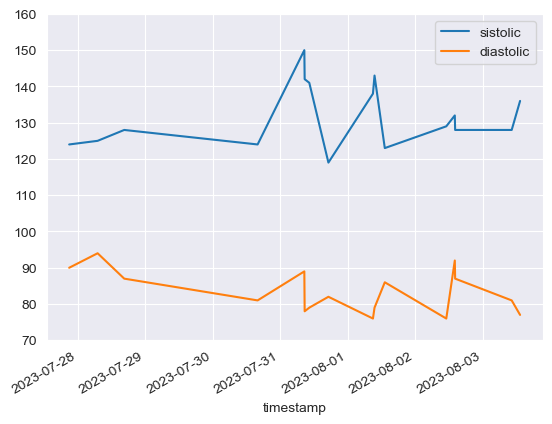

In [67]:
fig, ax = plt.subplots()
df.set_index("timestamp").plot(y=["sistolic", "diastolic"], ax=ax)
ax.set_ylim(70, 160)

In [114]:
per_hour = df\
    .assign(hour=lambda d: pd.to_datetime(d.hour))\
    .groupby("hour").agg({"sistolic": "mean", "diastolic": "mean"})\
    .resample("1h").mean()\
    .dropna(subset=["sistolic"])

/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_58335/1581203172.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .assign(hour=lambda d: pd.to_datetime(d.hour))\


(70.0, 160.0)

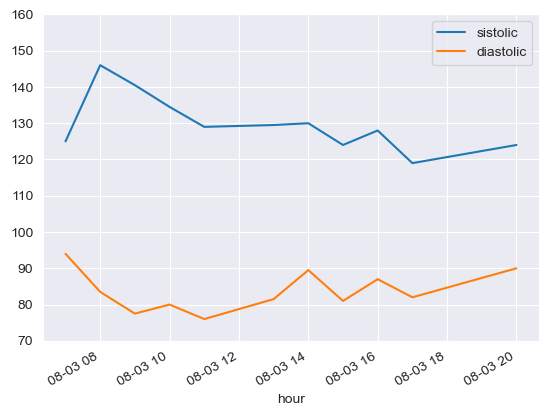

In [117]:
fig, ax = plt.subplots()
per_hour.plot(ax=ax)
ax.set_ylim(70, 160)